# DextraDemixerMulti

`DextraDemixerMulti` fits one independent `DextraDemixer` per pMHC. Compared to single-pMHC, setting `model.predict_posterior_class(max_prob=True)` resolve pMHC assignments over all pMHCs.
Every single fit stays reachable as `model.demixers[pmhc_key]`, `plot_results()` and the other single-pMHC diagnostics still work.

In [1]:
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score

try:
    from dextrademixer.model import DextraDemixerMulti
except ImportError:
    import sys
    sys.path.append('../..')
    from dextrademixer.model import DextraDemixerMulti

    warnings.warn(
        "DextraDemixer is not installed. Please install it with `pip install dextrademixer`." \
        "Fallback to using the local version of DextraDemixer."
    )

/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
%load_ext autoreload
%autoreload 2

## Fit every pMHC in one call

Compared to single epitope DextraDemixer: `PMHC_KEY` becomes `PMHC_KEYS`

In [3]:
PMHC_KEYS = ['pmhc1', 'pmhc2', 'pmhc3', ] 

In [4]:
# Dataset configs
PMHC_MODALITY_KEY = 'gex'  # modality key in mudata with multimer data, mudata.mod[PMHC_MODALITY_KEY]. Unused for adata/df
IR_MODALITY_KEY = 'airr'  # modality key of TCR with clone in mudata.mod[IR_MODALITY_KEY]. Unused for adata/df
CLONE_KEY = 'clone_id'  # key of clone_id in mudata.mod[IR_MODALITY_KEY].obs, may be ints or strings
LABEL_KEYS = {k: f'is_binder_{k}' for k in PMHC_KEYS}  # pMHC -> label key, only for evaluation, not needed for inference

# Model configs
# Relevant parameters get adjusted automatically based on MODEL_CONFIG (NEG_CTRL_KEY and CLONE_MEDIAN_P).
MODEL_CONFIG = 'DextraDemixer+clone'  # ['DextraDemixer', 'DextraDemixer+neg.', 'DextraDemixer+clone', 'DextraDemixer+neg.+clone']
NEG_CTRL_KEY = 'neg_control' if 'neg' in MODEL_CONFIG else None  # key of negative control pMHC in mudata.mod[PMHC_MODALITY_KEY].var, if None don't use negative control model
ALPHA_OFFSET = 5.0  # Offset of Negative Binomial scale parameter alpha for the specific group. Increase if model is trying to fit noise, decrease if antigen-specific component gets too narrow.

# Classification configs
# Choose either THRESHOLD or TARGET_FDR, not both.
THRESHOLD = 0.5  # If specified, predicted probability > THRESHOLD is used to classify antigen-specific binders.
CLONE_MEDIAN_P = 'clone' in MODEL_CONFIG  # If True, use clone-level median aggregation of predicted probabilities, if False, use cell-level predicted probabilities for classification.
TARGET_FDR = None  # If specified, the probability threshold is automatically determined to achieve the target FDR. Only THRESHOLD or TARGET_FDR can be specified, not both.
CRED_INTVL = None  # If specified, use credible interval bounded FDR control.

In [5]:
# Simulated 3-pMHC panel, regenerate with `python data/simulate_example_multi_pmhc.py`
data = mu.read('data/example_multi_pmhc.h5mu')
data


/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/yang.an/.local/share/mamba/envs/dextrademixer_minimal/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 5000 × 4
  2 modalities
    gex:	5000 x 4
      var:	'feature_types'
      uns:	'sim_params'
    airr:	5000 x 0
      obs:	'is_binder_pmhc1', 'is_binder_pmhc2', 'is_binder_pmhc3', 'clone_id'

In [6]:
# Initialize and fit one model per pMHC
model = DextraDemixerMulti(alpha_offset=ALPHA_OFFSET)
model.fit(data, pmhc_keys=PMHC_KEYS, pmhc_modality_key=PMHC_MODALITY_KEY,
          neg_ctrl_key=NEG_CTRL_KEY, ir_modality_key=IR_MODALITY_KEY, ir_clone_key=CLONE_KEY)

# Predict using the fitted models: both are cells x pMHC DataFrames
p_pred, assignment = model.predict_posterior_class(target_fdr=TARGET_FDR, threshold=THRESHOLD,
                                                  cred_intvl=CRED_INTVL,
                                                  clonotype_median_p=CLONE_MEDIAN_P)
print('fitted:', list(model.demixers))
p_pred.sample()

Fitting 1/3: pmhc1


100%|██████████| 1000/1000 [00:09<00:00, 105.91it/s, avg. loss [991-1000]: 18292.4634]


Fitting 2/3: pmhc2


100%|██████████| 1000/1000 [00:09<00:00, 104.91it/s, avg. loss [991-1000]: 16332.5314]


Fitting 3/3: pmhc3


100%|██████████| 1000/1000 [00:09<00:00, 102.92it/s, avg. loss [991-1000]: 12725.1442]


fitted: ['pmhc1', 'pmhc2', 'pmhc3']


,pmhc1,pmhc2,pmhc3
2979,0.000001,6.185468e-07,5.984332e-07


`max_prob=True` keeps, among the pMHCs whose
probability clears the threshold, only the one with the highest probability. Equal probabilities go
to the higher multimer count, then to the first pMHC; a cell with no call stays unassigned.

`max_prob` resolves whatever was thresholded, so `clonotype_median_p` sets the level and the two
options span a 2x2:

|                        | `max_prob=False`        | `max_prob=True`               |
| ---------------------- | ----------------------- | ----------------------------- |
| per-cell probability   | every call kept         | one call per cell             |
| clonotype median (`clonotype_median_p=True`) | every call kept, clone-uniform | one call per clonotype |

Note that resolution *destroys* multi-assignments, so leave `max_prob=False` if genuinely
cross-reactive cells are expected: the argmax cannot tell cross-reactivity from spillover.


In [7]:
# Log metrics per pMHC
obs = data.mod[IR_MODALITY_KEY].obs if isinstance(data, mu.MuData) else getattr(data, 'obs', data)

def score(assignment, p_pred):
    rows = {}
    for pmhc_key, label_key in LABEL_KEYS.items():
        y_true = obs[label_key].astype(int).values
        y_pred, p = assignment[pmhc_key].to_numpy(), p_pred[pmhc_key].to_numpy()
        rows[pmhc_key] = {'n_called': int(y_pred.sum()), 'f1': f1_score(y_true, y_pred),
                          'precision': precision_score(y_true, y_pred, zero_division=0),
                          'recall': recall_score(y_true, y_pred),
                          'aps': average_precision_score(y_true, p)}
    return pd.DataFrame(rows).T.rename_axis('pMHC')

In [8]:
variants = {
    'raw': dict(),
    'clonotype_median_p': dict(clonotype_median_p=True),
    'max_prob (cell)': dict(max_prob=True),
    'max_prob (clone)': dict(clonotype_median_p=True, max_prob=True),
}
assignments, probs = {}, {}
for name, kw in variants.items():
    probs[name], assignments[name] = model.predict_posterior_class(threshold=THRESHOLD, **kw)


In [9]:
# does the resolution cost accuracy?
pd.concat({name: score(a, probs[name]) for name, a in assignments.items()},
          names=['strategy', 'pMHC'])[['f1', 'precision', 'recall']].round(3)


f1  precision  recall
strategy           pMHC                           
raw                pmhc1  0.946      0.987   0.909
                   pmhc2  0.855      0.953   0.776
                   pmhc3  0.770      0.971   0.638
clonotype_median_p pmhc1  1.000      1.000   1.000
                   pmhc2  1.000      1.000   1.000
                   pmhc3  0.974      1.000   0.950
max_prob (cell)    pmhc1  0.948      0.991   0.909
                   pmhc2  0.859      0.962   0.776
                   pmhc3  0.770      0.971   0.638
max_prob (clone)   pmhc1  1.000      1.000   1.000
                   pmhc2  1.000      1.000   1.000
                   pmhc3  0.974      1.000   0.950

pmhc1


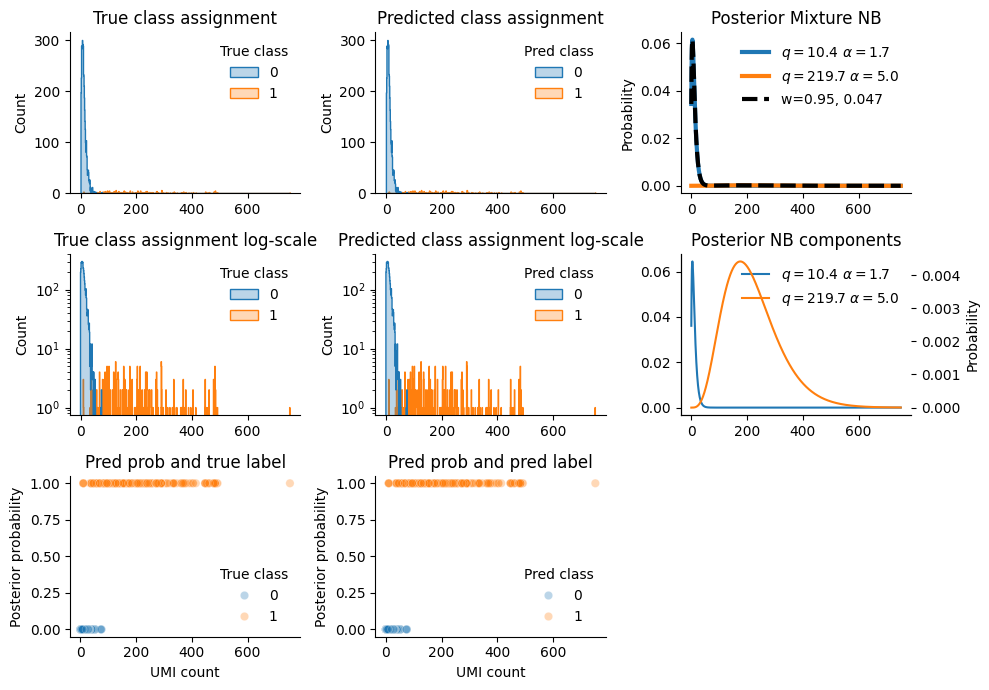

pmhc2


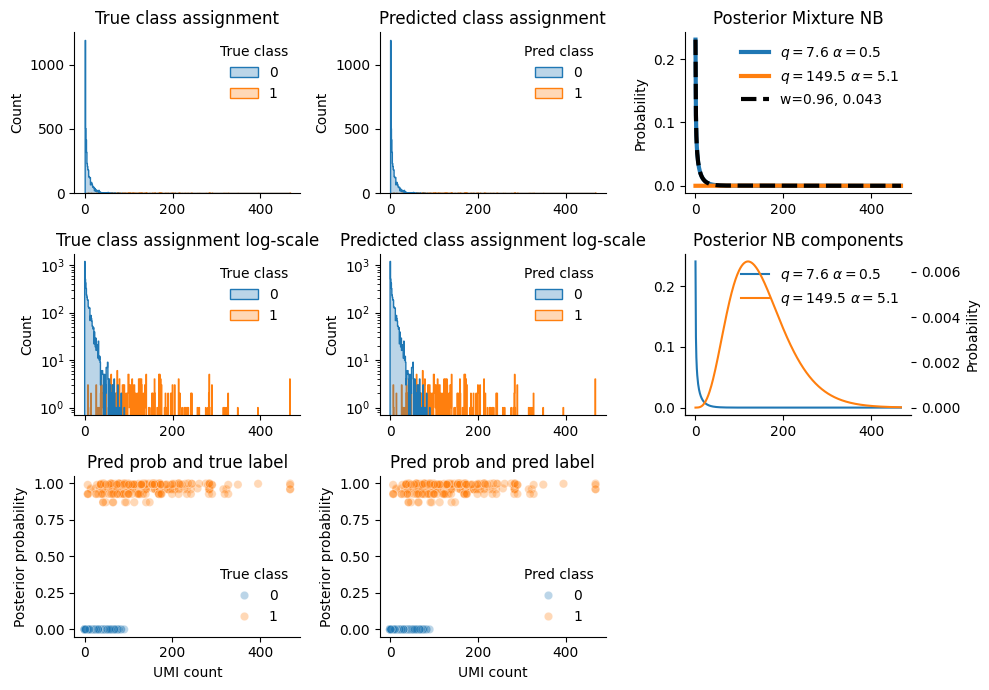

pmhc3


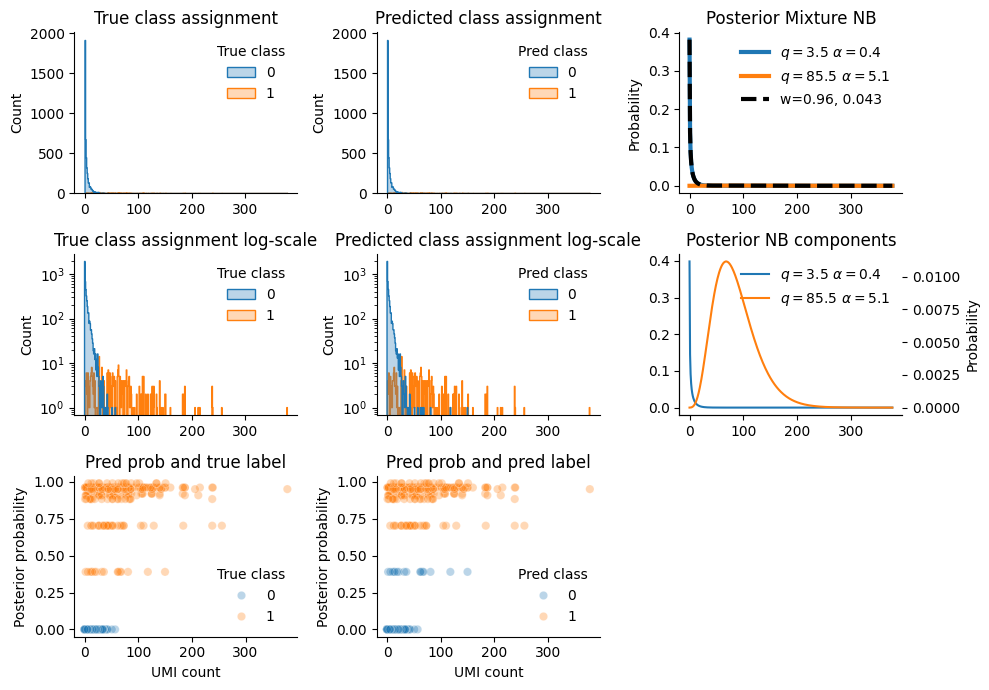

In [10]:
# Plot results per pMHC
for pmhc_key, label_key in LABEL_KEYS.items():
    print(pmhc_key)
    model.demixers[pmhc_key].plot_results(assignment=assignment[pmhc_key].to_numpy(),
                                          p_pred=p_pred[pmhc_key].to_numpy(),
                                          y_true=obs[label_key].astype(int).values,
                                          show=True)